# 03 — WoE Scorecard
Primary model — logistic regression on WoE-transformed features. Basel IRB standard approach.

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from pathlib import Path
from optbinning import BinningProcess
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import calibration_curve

PROC = Path('../Data/Processed')
OUT  = Path('../Outputs')

df = pd.read_parquet(PROC / 'master_features.parquet').sort_values('SK_ID_CURR')

with open(PROC / 'selected_features.json') as f:
    selected_features = json.load(f)

## 1. Train / out-of-time split

In [2]:
# same 80/20 split as NB04 — sorted by SK_ID_CURR so earlier IDs train, later IDs test
split = int(len(df) * 0.8)
train = df.iloc[:split]
oot   = df.iloc[split:]

print(f"Train: {len(train):,} rows | Default rate: {train['TARGET'].mean():.2%}")
print(f"OOT:   {len(oot):,} rows  | Default rate: {oot['TARGET'].mean():.2%}")

Train: 246,008 rows | Default rate: 8.11%
OOT:   61,503 rows  | Default rate: 7.94%


## 2. WoE binning

In [3]:
# identify categorical features for the binning process
cat_features = [f for f in selected_features if df[f].dtype == 'object']

binning = BinningProcess(
    variable_names=selected_features,
    categorical_variables=cat_features,
    min_bin_size=0.05,  # each bin must contain at least 5% of the population
    max_n_bins=8,
)
binning.fit(train[selected_features], train['TARGET'])

X_train_woe = binning.transform(train[selected_features], metric='woe')
X_oot_woe   = binning.transform(oot[selected_features],   metric='woe')

# print each variable's binning table — WoE should be monotone
for var in selected_features:
    print(f"\n--- {var} ---")
    print(binning.get_binned_variable(var).binning_table.build())


--- ext_source_mean ---
                 Bin   Count  Count (%)  Non-event  Event  Event rate  \
0       (-inf, 0.26)   15489   0.062961      11482   4007    0.258700   
1       [0.26, 0.33)   16347   0.066449      13440   2907    0.177831   
2       [0.33, 0.39)   21338   0.086737      18497   2841    0.133143   
3       [0.39, 0.48)   44285   0.180014      40303   3982    0.089918   
4       [0.48, 0.55)   43883   0.178380      41211   2672    0.060889   
5       [0.55, 0.64)   51818   0.210635      49652   2166    0.041800   
6       [0.64, 0.68)   23744   0.096517      22986    758    0.031924   
7        [0.68, inf)   28955   0.117699      28360    595    0.020549   
8            Special       0   0.000000          0      0    0.000000   
9            Missing     149   0.000606        136     13    0.087248   
Totals                246008   1.000000     226067  19941    0.081058   

             WoE        IV            JS  
0      -1.375316  0.206507  2.395382e-02  
1       -0.8

## 3. Logistic regression

In [4]:
lr = LogisticRegression(penalty='l2', C=1.0, solver='lbfgs', max_iter=1000, random_state=42)
lr.fit(X_train_woe, train['TARGET'])

# coefficients — positive coef = higher WoE = higher predicted risk
coef_df = pd.DataFrame({'feature': selected_features, 'coefficient': lr.coef_[0]})
print(coef_df.sort_values('coefficient').to_string(index=False))

             feature  coefficient
credit_annuity_ratio    -0.643671
         OWN_CAR_AGE    -0.605768
        EXT_SOURCE_2    -0.537936
        EXT_SOURCE_3    -0.535310
  credit_goods_ratio    -0.477100
     AMT_GOODS_PRICE    -0.467080
 NAME_EDUCATION_TYPE    -0.464281
      cc_utilisation    -0.457972
       inst_max_late    -0.454707
   ORGANIZATION_TYPE    -0.444884
        EXT_SOURCE_1    -0.375607
   bureau_debt_ratio    -0.349036
     OCCUPATION_TYPE    -0.333093
  employed_age_ratio    -0.234402
      employed_years    -0.224791
     ext_source_mean    -0.194745
    NAME_INCOME_TYPE    -0.175829
      inst_late_rate    -0.158351
       inst_avg_diff    -0.151717
      cc_avg_balance    -0.136741
     bureau_avg_days    -0.101350
      ext_source_min    -0.093481
           age_years     0.054735
     inst_late_count     0.076708
      cc_avg_payment     0.097871


## 4. Convert to scorecard points

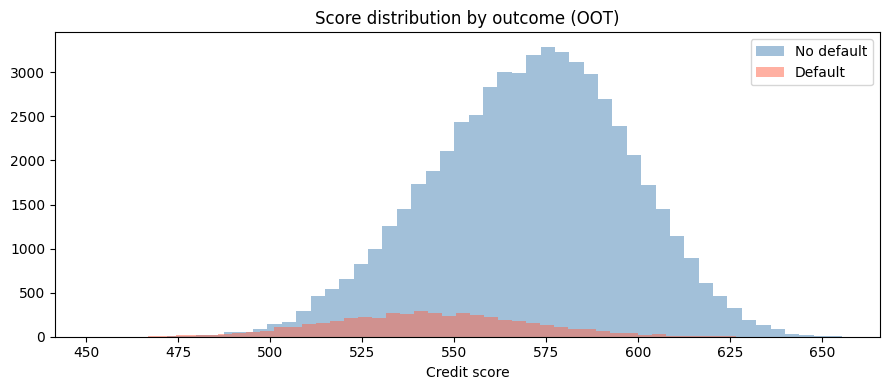

In [5]:
# standard scorecard scaling: PDO=20, base score=600 at 50:1 odds
PDO, base_score, base_odds = 20, 600, 50
factor = PDO / np.log(2)
offset = base_score - factor * np.log(base_odds)

# convert predicted probability to score — higher score = lower risk
y_pred_proba = lr.predict_proba(X_oot_woe)[:, 1]
oot_scores   = offset + factor * np.log((1 - y_pred_proba) / y_pred_proba)

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(oot_scores[oot['TARGET'] == 0], bins=50, alpha=0.5, label='No default', color='steelblue')
ax.hist(oot_scores[oot['TARGET'] == 1], bins=50, alpha=0.5, label='Default',    color='tomato')
ax.set_xlabel('Credit score')
ax.set_title('Score distribution by outcome (OOT)')
ax.legend()
plt.tight_layout()
plt.savefig(OUT / 'score_distribution.png', dpi=100)
plt.show()

## 5. Calibration check

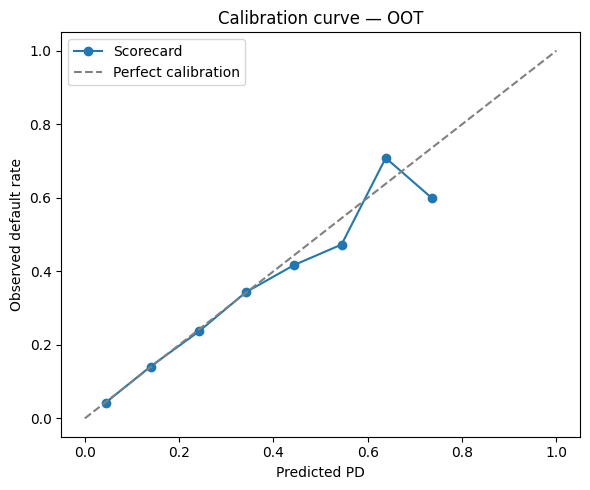

Saved lr_model.pkl and binning.pkl


In [6]:
prob_true, prob_pred = calibration_curve(oot['TARGET'], y_pred_proba, n_bins=10)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(prob_pred, prob_true, 'o-', label='Scorecard')
ax.plot([0, 1], [0, 1], '--', color='grey', label='Perfect calibration')
ax.set_xlabel('Predicted PD')
ax.set_ylabel('Observed default rate')
ax.set_title('Calibration curve — OOT')
ax.legend()
plt.tight_layout()
plt.savefig(OUT / 'calibration.png', dpi=100)
plt.show()

# save model and binning object for NB05
joblib.dump(lr,      OUT / 'lr_model.pkl')
joblib.dump(binning, OUT / 'binning.pkl')
print("Saved lr_model.pkl and binning.pkl")